# EDA - PetFinder Adoption Prediction

Este notebook realiza un analisis exploratorio de datos (EDA) sobre el dataset **PetFinder Adoption Prediction**, con foco en una futura tarea de **clasificacion/prediccion** de la variable objetivo `AdoptionSpeed`.

Objetivos del analisis:
- entender la estructura del dataset,
- revisar calidad de datos,
- estudiar la distribucion de la variable objetivo,
- explorar variables numericas y categoricas,
- detectar relaciones utiles y posibles outliers.

> En esta etapa no se realiza feature engineering ni entrenamiento de modelos.

In [2]:
# Imports
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Configuracion visual
sns.set_theme(style="whitegrid", palette="deep")
plt.rcParams["figure.figsize"] = (10, 5)
plt.rcParams["axes.titlesize"] = 13
plt.rcParams["axes.labelsize"] = 11

## Carga del dataset

Cargamos el archivo de entrenamiento en un DataFrame llamado `dataset`.

In [3]:
# Carga del dataset
DATA_PATH = "../input/petfinder-adoption-prediction/train/train.csv"

dataset = pd.read_csv(DATA_PATH)

print(f"Shape del dataset: {dataset.shape[0]} filas x {dataset.shape[1]} columnas")
dataset.head()

Shape del dataset: 14993 filas x 24 columnas


,Type,Name,Age,Breed1,Breed2,Gender,Color1,Color2,Color3,MaturitySize,...,Health,Quantity,Fee,State,RescuerID,VideoAmt,Description,PetID,PhotoAmt,AdoptionSpeed
0,2,Nibble,3,299,0,1,1,7,0,1,...,1,1,100,41326,8480853f516546f6cf33aa88cd76c379,0,Nibble is a 3+ month old ball of cuteness. He ...,86e1089a3,1.0,2
1,2,No Name Yet,1,265,0,1,1,2,0,2,...,1,1,0,41401,3082c7125d8fb66f7dd4bff4192c8b14,0,I just found it alone yesterday near my apartm...,6296e909a,2.0,0
2,1,Brisco,1,307,0,1,2,7,0,2,...,1,1,0,41326,fa90fa5b1ee11c86938398b60abc32cb,0,Their pregnant mother was dumped by her irresp...,3422e4906,7.0,3
3,1,Miko,4,307,0,2,1,2,0,2,...,1,1,150,41401,9238e4f44c71a75282e62f7136c6b240,0,"Good guard dog, very alert, active, obedience ...",5842f1ff5,8.0,2
4,1,Hunter,1,307,0,1,1,0,0,2,...,1,1,0,41326,95481e953f8aed9ec3d16fc4509537e8,0,This handsome yet cute boy is up for adoption....,850a43f90,3.0,2


## Vista general del dataset

Revisamos dimensiones, nombres de columnas y una muestra inicial para entender la estructura general.

In [4]:
print("Columnas del dataset:")
print(dataset.columns.tolist())

Columnas del dataset:
['Type', 'Name', 'Age', 'Breed1', 'Breed2', 'Gender', 'Color1', 'Color2', 'Color3', 'MaturitySize', 'FurLength', 'Vaccinated', 'Dewormed', 'Sterilized', 'Health', 'Quantity', 'Fee', 'State', 'RescuerID', 'VideoAmt', 'Description', 'PetID', 'PhotoAmt', 'AdoptionSpeed']


In [5]:
dataset.sample(5, random_state=42)

,Type,Name,Age,Breed1,Breed2,Gender,Color1,Color2,Color3,MaturitySize,...,Health,Quantity,Fee,State,RescuerID,VideoAmt,Description,PetID,PhotoAmt,AdoptionSpeed
13408,1,â¥â¥â¥ Lily â¥â¥â¥,36,307,0,2,2,7,0,2,...,1,1,0,41326,337914b09c2fa5460e195197e994ef98,0,Adorable 3 year old Lily looking for a forever...,3f8824a3b,1.0,4
6472,2,Cookie,3,266,0,1,6,7,0,2,...,1,1,0,41327,4bb1ebb92158078ad54a6bb23c10dffc,0,i rescue this stary kitten from market near my...,9238eb7fc,1.0,2
9967,2,Favour Speedy Abundance And Courage,7,250,252,1,1,2,0,2,...,1,4,0,41327,99ba8ce53b4d8515e417e7921563d923,0,The mother was a Burmese cross and had since p...,f0a1f2b90,2.0,4
862,1,NaN,3,307,0,1,2,0,0,3,...,1,1,0,41327,3f3ef74c486beba3bc87f6dbaee772bf,0,This puppy is: 1. Male 2. 3 months old 3. Brow...,7d028bdea,4.0,2
5967,2,Abandoned Kitty,1,266,0,1,1,6,7,1,...,1,1,0,41401,844f03ab8054007d4be6686f3a9702b9,0,Mother cat gave birth to a litter of 3 and too...,8377bfe97,0.0,2


In [6]:
dataset.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 14993 entries, 0 to 14992
Data columns (total 24 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Type           14993 non-null  int64  
 1   Name           13728 non-null  object 
 2   Age            14993 non-null  int64  
 3   Breed1         14993 non-null  int64  
 4   Breed2         14993 non-null  int64  
 5   Gender         14993 non-null  int64  
 6   Color1         14993 non-null  int64  
 7   Color2         14993 non-null  int64  
 8   Color3         14993 non-null  int64  
 9   MaturitySize   14993 non-null  int64  
 10  FurLength      14993 non-null  int64  
 11  Vaccinated     14993 non-null  int64  
 12  Dewormed       14993 non-null  int64  
 13  Sterilized     14993 non-null  int64  
 14  Health         14993 non-null  int64  
 15  Quantity       14993 non-null  int64  
 16  Fee            14993 non-null  int64  
 17  State          14993 non-null  int64  
 18  Rescue

## Diccionario de variables

A continuacion se resume el significado de las variables principales del dataset:

- `Type`: tipo de mascota. Usualmente `1 = Dog`, `2 = Cat`.
- `Name`: nombre de la mascota.
- `Age`: edad en meses.
- `Breed1`: raza principal.
- `Breed2`: raza secundaria, si la mascota es mestiza.
- `Gender`: sexo de la mascota.
- `Color1`, `Color2`, `Color3`: colores de la mascota.
- `MaturitySize`: tamano esperado en la adultez. Valores tipicos: `1 = Small`, `2 = Medium`, `3 = Large`, `4 = Extra Large`, `0 = Not Specified`.
- `FurLength`: longitud del pelaje.
- `Vaccinated`: estado de vacunacion. Valores tipicos: `1 = Yes`, `2 = No`, `3 = Not Sure`.
- `Dewormed`: estado de desparasitacion. Valores tipicos: `1 = Yes`, `2 = No`, `3 = Not Sure`.
- `Sterilized`: esterilizacion/castracion. Valores tipicos: `1 = Yes`, `2 = No`, `3 = Not Sure`.
- `Health`: estado de salud de la mascota.
- `Quantity`: cantidad de mascotas incluidas en la publicacion.
- `Fee`: costo o tarifa de adopcion.
- `State`: estado o region de Malasia.
- `RescuerID`: identificador del rescatista o publicador.
- `VideoAmt`: cantidad de videos asociados a la publicacion.
- `Description`: descripcion textual de la mascota.
- `PetID`: identificador unico de la mascota.
- `PhotoAmt`: cantidad de fotos asociadas a la publicacion.
- `AdoptionSpeed`: variable objetivo. Valores menores indican una adopcion mas rapida.

Observaciones importantes para el analisis:
- `Breed1`, `Breed2`, `Color1`, `Color2`, `Color3` y `State` son codigos numericos, no etiquetas legibles directamente.
- `Name` y `Description` son variables de texto.
- `RescuerID` y `PetID` funcionan como identificadores.
- `AdoptionSpeed` es la variable a predecir en la futura tarea de clasificacion.

## Tipos de variables

En este dataset hay una mezcla de:
- variables numericas continuas/discretas,
- variables categoricas codificadas como enteros,
- variables de texto,
- identificadores.

Para un EDA orientado a clasificacion, conviene distinguir entre:
1. variables numericas "reales",
2. variables categoricas codificadas,
3. variables de texto/ID.

In [7]:
# Definicion manual de grupos de variables
target_col = "AdoptionSpeed"

numeric_cols = ["Age", "Quantity", "Fee", "VideoAmt", "PhotoAmt"]
categorical_cols = [
    "Type", "Breed1", "Breed2", "Gender", "Color1", "Color2", "Color3",
    "MaturitySize", "FurLength", "Vaccinated", "Dewormed", "Sterilized",
    "Health", "State"
]
text_cols = ["Name", "Description"]
id_cols = ["RescuerID", "PetID"]

print("Variables numericas:")
print(numeric_cols)

print("\nVariables categoricas codificadas:")
print(categorical_cols)

print("\nVariables de texto:")
print(text_cols)

print("\nVariables identificadoras:")
print(id_cols)

Variables numericas:
['Age', 'Quantity', 'Fee', 'VideoAmt', 'PhotoAmt']

Variables categoricas codificadas:
['Type', 'Breed1', 'Breed2', 'Gender', 'Color1', 'Color2', 'Color3', 'MaturitySize', 'FurLength', 'Vaccinated', 'Dewormed', 'Sterilized', 'Health', 'State']

Variables de texto:
['Name', 'Description']

Variables identificadoras:
['RescuerID', 'PetID']


In [8]:
# Resumen de tipos por columna
type_summary = pd.DataFrame({
    "dtype": dataset.dtypes.astype(str),
    "n_unique": dataset.nunique(),
    "missing": dataset.isna().sum()
}).sort_values(by=["dtype", "n_unique"])

type_summary

,dtype,n_unique,missing
PhotoAmt,float64,31,0
Type,int64,2,0
Gender,int64,3,0
FurLength,int64,3,0
Vaccinated,int64,3,0
Dewormed,int64,3,0
Sterilized,int64,3,0
Health,int64,3,0
MaturitySize,int64,4,0
AdoptionSpeed,int64,5,0


## Missing values

Analizamos valores faltantes para identificar problemas de calidad de datos y anticipar decisiones de preprocesamiento.

In [9]:
missing_df = pd.DataFrame({
    "missing_count": dataset.isna().sum(),
    "missing_pct": dataset.isna().mean().mul(100).round(2)
}).sort_values("missing_count", ascending=False)

missing_df[missing_df["missing_count"] > 0]

,missing_count,missing_pct
Name,1265,8.44
Description,13,0.09


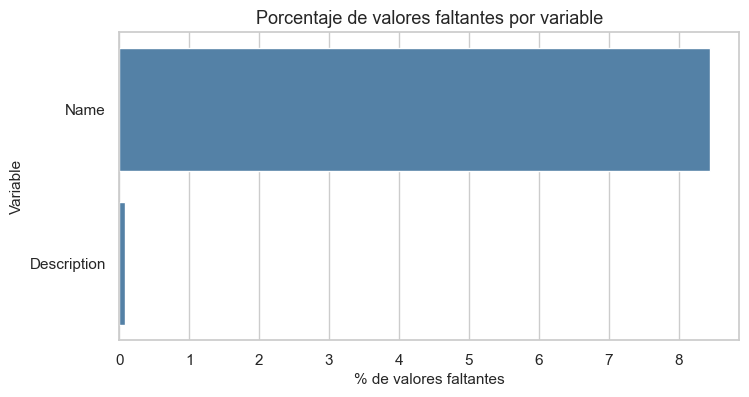

In [10]:
# Visualizacion simple de missing values
missing_plot = missing_df[missing_df["missing_count"] > 0].reset_index()
missing_plot.columns = ["variable", "missing_count", "missing_pct"]

if not missing_plot.empty:
    plt.figure(figsize=(8, 4))
    sns.barplot(data=missing_plot, x="missing_pct", y="variable", color="steelblue")
    plt.title("Porcentaje de valores faltantes por variable")
    plt.xlabel("% de valores faltantes")
    plt.ylabel("Variable")
    plt.show()
else:
    print("No se detectaron valores faltantes.")

## Resumen estadistico

Obtenemos un resumen de las variables numericas y tambien una vista resumida de variables categoricas/codigo.

In [11]:
dataset[numeric_cols].describe().T

,count,mean,std,min,25%,50%,75%,max
Age,14993.0,10.452078,18.155790,0.0,2.0,3.0,12.0,255.0
Quantity,14993.0,1.576069,1.472477,1.0,1.0,1.0,1.0,20.0
Fee,14993.0,21.259988,78.414548,0.0,0.0,0.0,0.0,3000.0
VideoAmt,14993.0,0.056760,0.346185,0.0,0.0,0.0,0.0,8.0
PhotoAmt,14993.0,3.889215,3.487810,0.0,2.0,3.0,5.0,30.0


In [12]:
dataset[categorical_cols + [target_col]].describe().T

,count,mean,std,min,25%,50%,75%,max
Type,14993.0,1.457614,0.498217,1.0,1.0,1.0,2.0,2.0
Breed1,14993.0,265.272594,60.056818,0.0,265.0,266.0,307.0,307.0
Breed2,14993.0,74.009738,123.011575,0.0,0.0,0.0,179.0,307.0
Gender,14993.0,1.776162,0.681592,1.0,1.0,2.0,2.0,3.0
Color1,14993.0,2.234176,1.745225,1.0,1.0,2.0,3.0,7.0
Color2,14993.0,3.222837,2.742562,0.0,0.0,2.0,6.0,7.0
Color3,14993.0,1.882012,2.984086,0.0,0.0,0.0,5.0,7.0
MaturitySize,14993.0,1.862002,0.547959,1.0,2.0,2.0,2.0,4.0
FurLength,14993.0,1.467485,0.599070,1.0,1.0,1.0,2.0,3.0
Vaccinated,14993.0,1.731208,0.667649,1.0,1.0,2.0,2.0,3.0


## Analisis de la variable objetivo `AdoptionSpeed`

`AdoptionSpeed` es la variable a predecir. Revisamos su distribucion para detectar posible desbalance de clases.

Interpretacion habitual:
- `0`: adopcion muy rapida
- `4`: no adoptado / adopcion muy lenta

In [13]:
target_counts = dataset[target_col].value_counts().sort_index()
target_pct = dataset[target_col].value_counts(normalize=True).sort_index().mul(100).round(2)

target_summary = pd.DataFrame({
    "count": target_counts,
    "percentage": target_pct
})

target_summary

,count,percentage
AdoptionSpeed,,
0,410,2.73
1,3090,20.61
2,4037,26.93
3,3259,21.74
4,4197,27.99


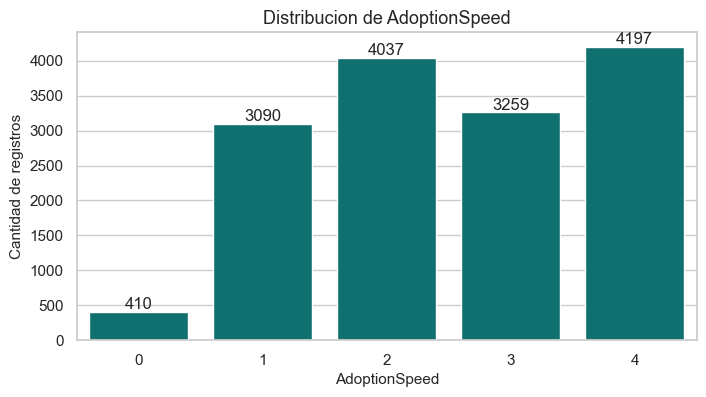

In [14]:
plt.figure(figsize=(8, 4))
ax = sns.countplot(data=dataset, x=target_col, order=sorted(dataset[target_col].unique()), color="teal")
plt.title("Distribucion de AdoptionSpeed")
plt.xlabel("AdoptionSpeed")
plt.ylabel("Cantidad de registros")

for p in ax.patches:
    ax.annotate(
        f"{int(p.get_height())}",
        (p.get_x() + p.get_width() / 2, p.get_height()),
        ha="center",
        va="bottom"
    )

plt.show()

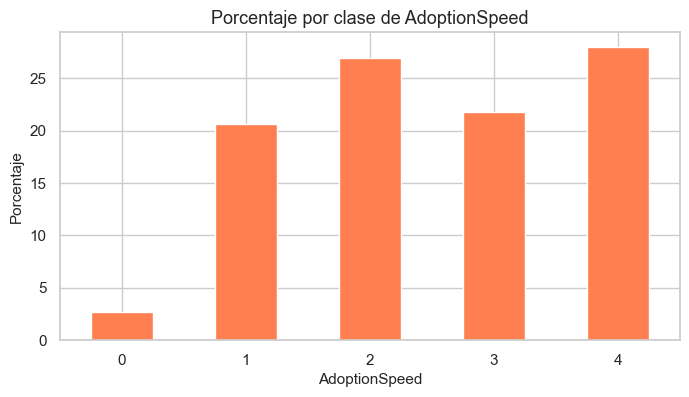

In [15]:
plt.figure(figsize=(8, 4))
target_pct.plot(kind="bar", color="coral")
plt.title("Porcentaje por clase de AdoptionSpeed")
plt.xlabel("AdoptionSpeed")
plt.ylabel("Porcentaje")
plt.xticks(rotation=0)
plt.show()

## Analisis univariado de variables numericas

Exploramos la distribucion de las variables numericas mas relevantes para modelado.

In [16]:
dataset[numeric_cols].describe().T

,count,mean,std,min,25%,50%,75%,max
Age,14993.0,10.452078,18.155790,0.0,2.0,3.0,12.0,255.0
Quantity,14993.0,1.576069,1.472477,1.0,1.0,1.0,1.0,20.0
Fee,14993.0,21.259988,78.414548,0.0,0.0,0.0,0.0,3000.0
VideoAmt,14993.0,0.056760,0.346185,0.0,0.0,0.0,0.0,8.0
PhotoAmt,14993.0,3.889215,3.487810,0.0,2.0,3.0,5.0,30.0


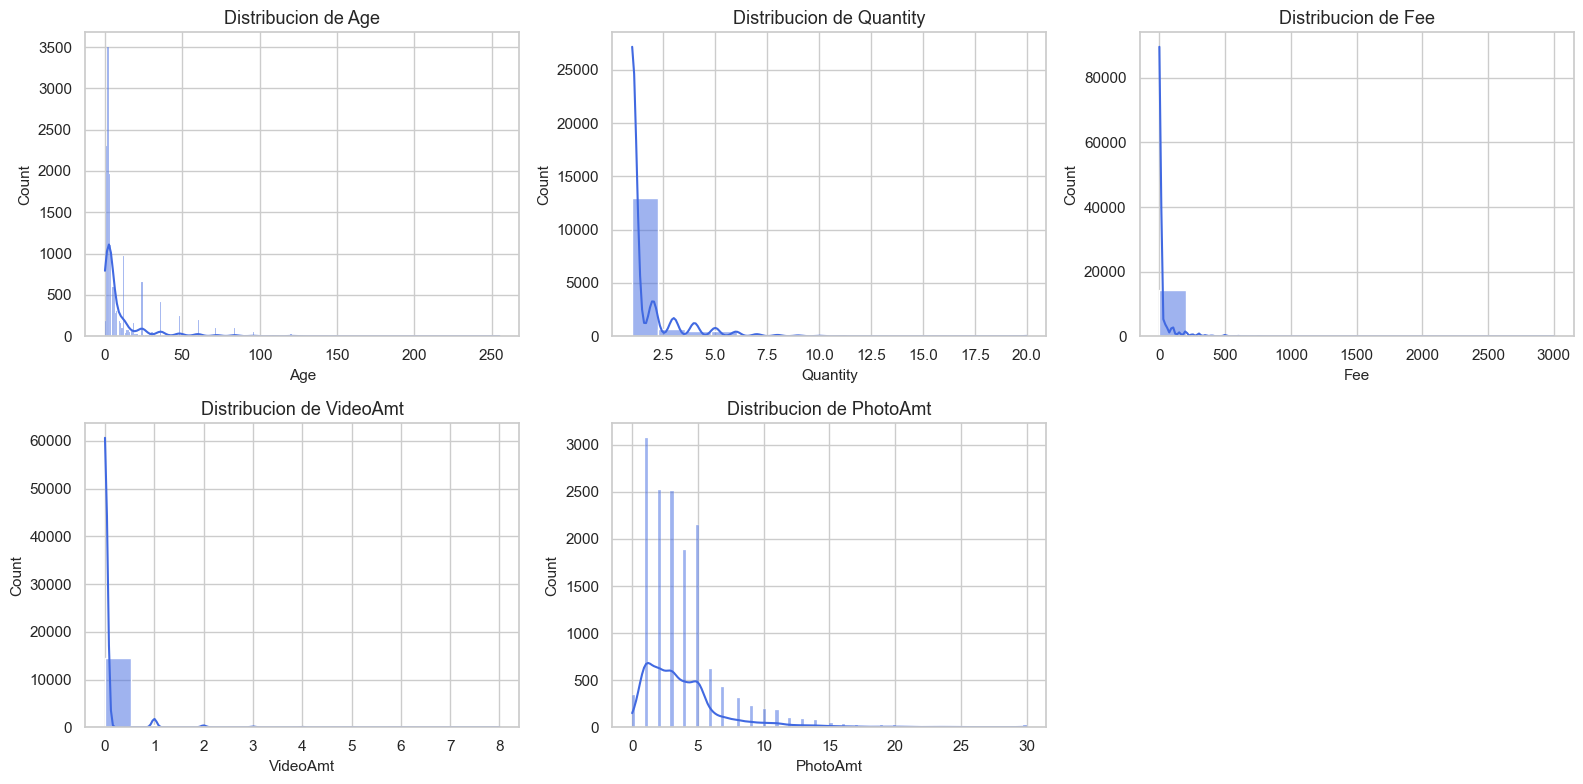

In [17]:
# Histogramas
fig, axes = plt.subplots(2, 3, figsize=(16, 8))
axes = axes.flatten()

for i, col in enumerate(numeric_cols):
    sns.histplot(dataset[col], kde=True, ax=axes[i], color="royalblue")
    axes[i].set_title(f"Distribucion de {col}")

for j in range(len(numeric_cols), len(axes)):
    axes[j].axis("off")

plt.tight_layout()
plt.show()

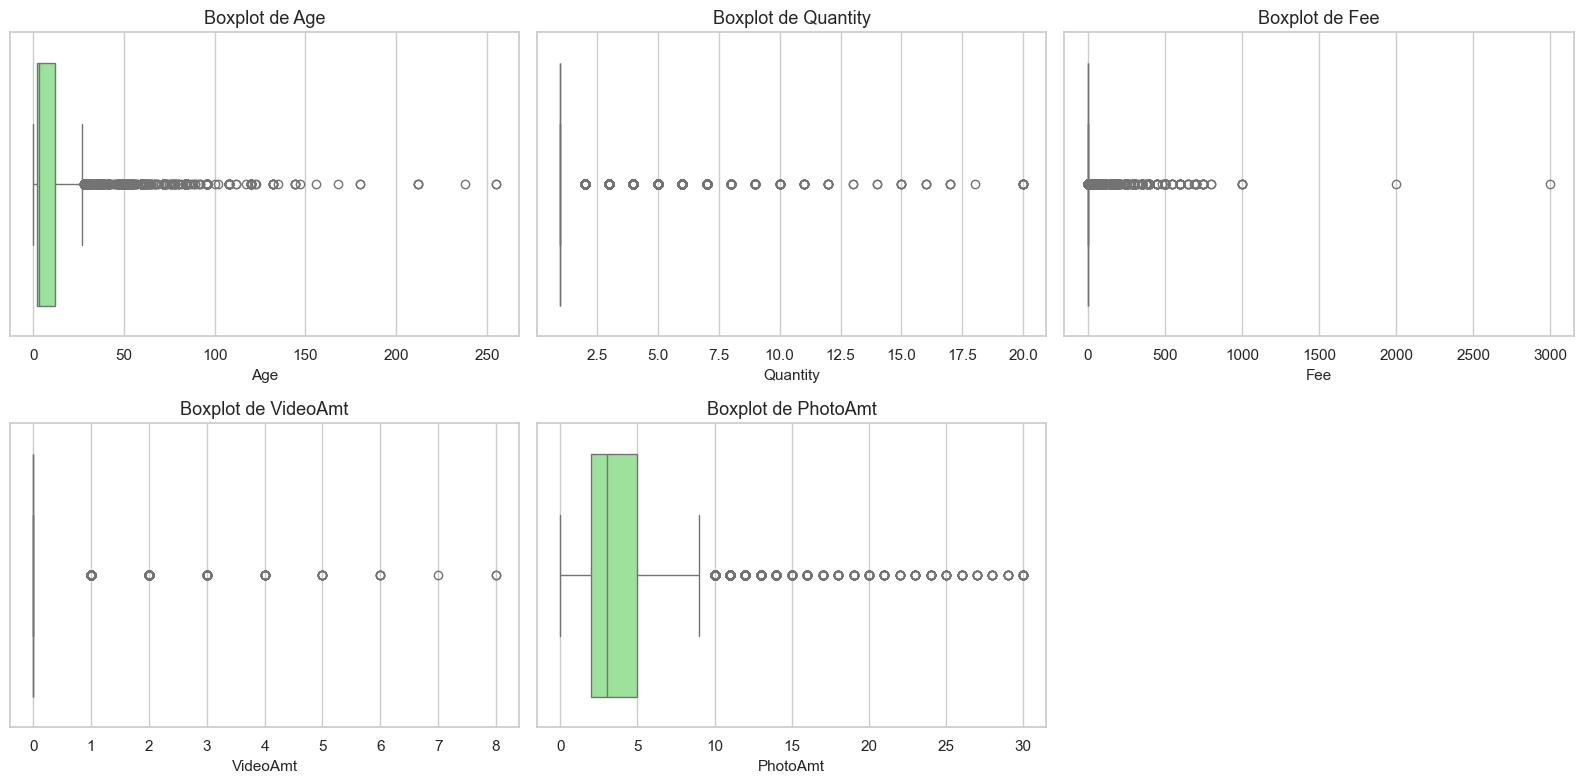

In [18]:
# Boxplots para una revision rapida de dispersion y posibles valores extremos
fig, axes = plt.subplots(2, 3, figsize=(16, 8))
axes = axes.flatten()

for i, col in enumerate(numeric_cols):
    sns.boxplot(x=dataset[col], ax=axes[i], color="lightgreen")
    axes[i].set_title(f"Boxplot de {col}")

for j in range(len(numeric_cols), len(axes)):
    axes[j].axis("off")

plt.tight_layout()
plt.show()

### Relacion simple entre variables numericas y la variable objetivo

Aunque no entrenamos modelos todavia, es util ver si hay patrones entre las variables numericas y `AdoptionSpeed`.

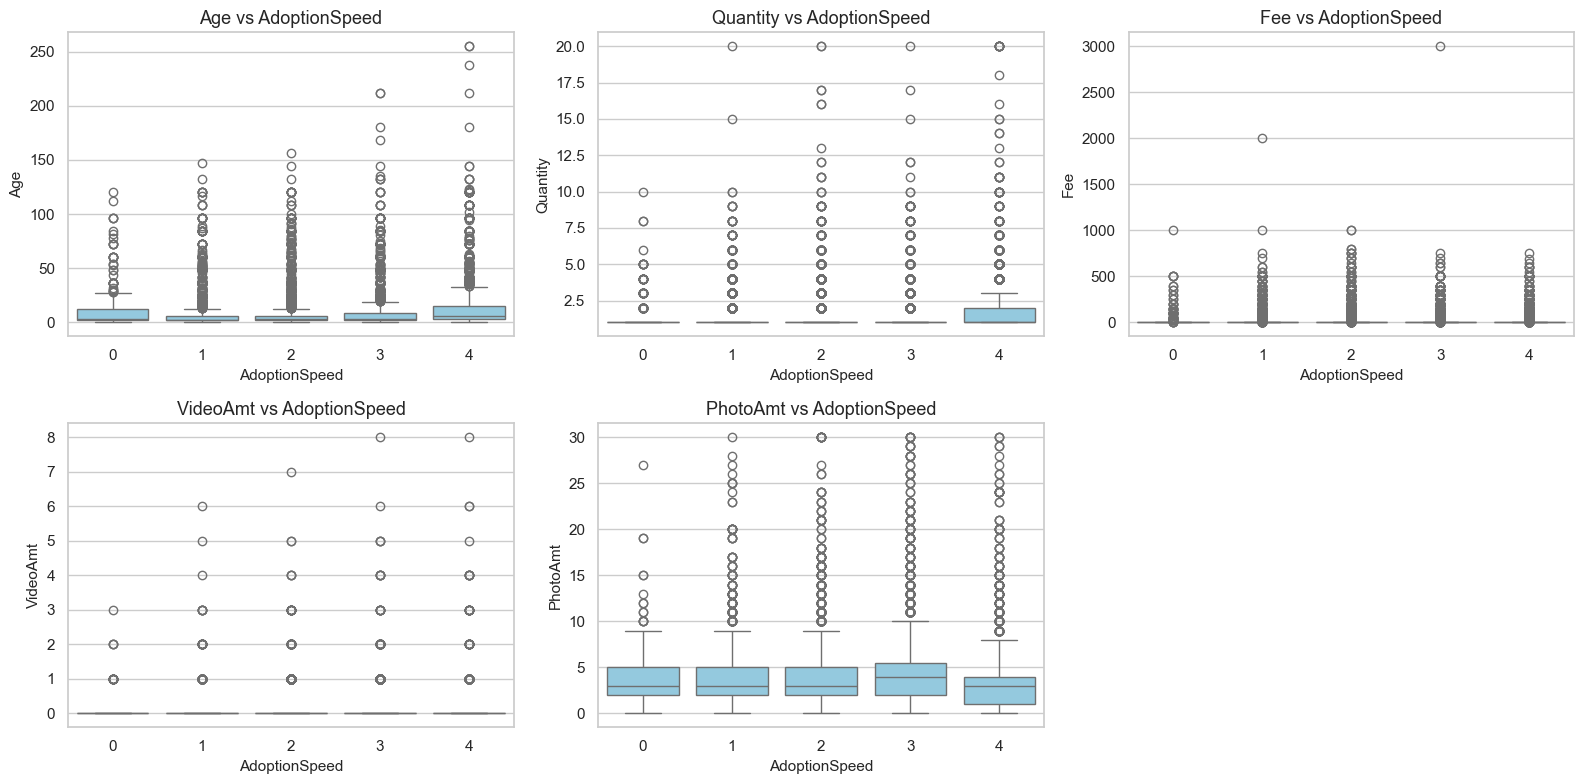

In [19]:
fig, axes = plt.subplots(2, 3, figsize=(16, 8))
axes = axes.flatten()

for i, col in enumerate(numeric_cols):
    sns.boxplot(data=dataset, x=target_col, y=col, ax=axes[i], color="skyblue")
    axes[i].set_title(f"{col} vs AdoptionSpeed")

for j in range(len(numeric_cols), len(axes)):
    axes[j].axis("off")

plt.tight_layout()
plt.show()

## Analisis univariado de variables categoricas

Revisamos variables categoricas codificadas que podrian aportar senal predictiva.
Para evitar graficos excesivos, mostramos primero las mas relevantes y luego un resumen tabular de cardinalidad.

In [20]:
cat_summary = pd.DataFrame({
    "n_unique": dataset[categorical_cols].nunique(),
    "top_value": dataset[categorical_cols].mode().iloc[0],
    "top_freq": dataset[categorical_cols].apply(lambda x: x.value_counts().iloc[0])
}).sort_values("n_unique", ascending=False)

cat_summary

,n_unique,top_value,top_freq
Breed1,176,307,5927
Breed2,135,0,10762
State,14,41326,8714
Color1,7,1,7427
Color2,7,0,4471
Color3,6,0,10604
MaturitySize,4,2,10305
Gender,3,2,7277
FurLength,3,1,8808
Vaccinated,3,2,7227


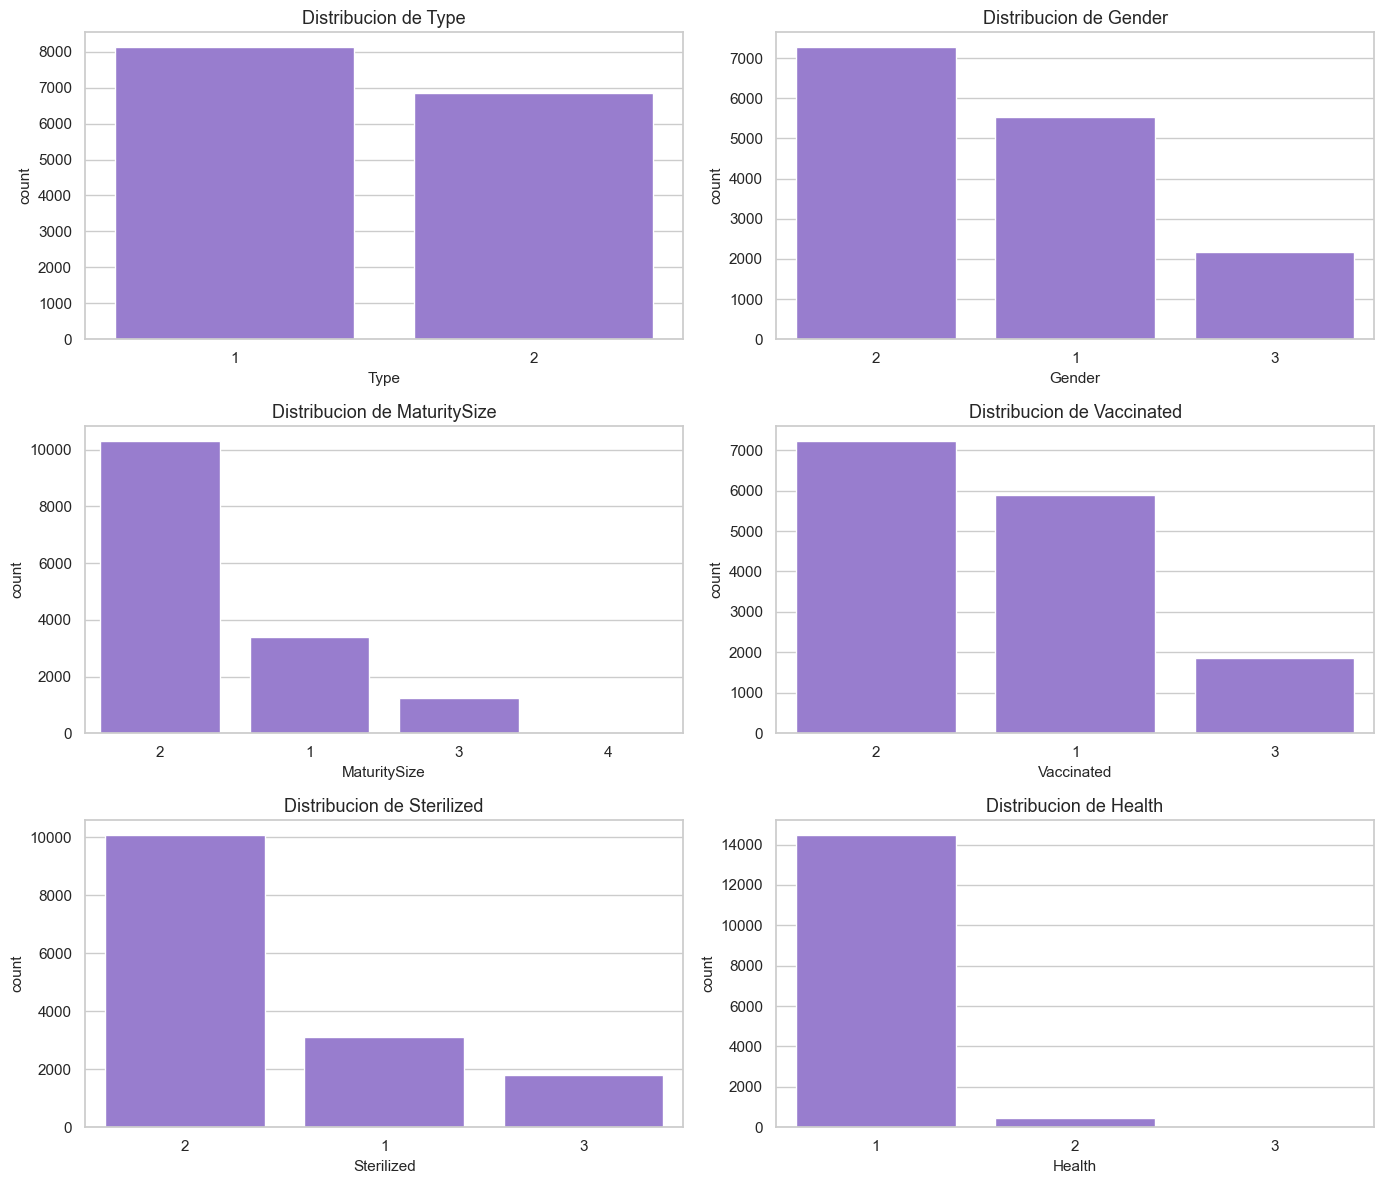

In [21]:
selected_cats = ["Type", "Gender", "MaturitySize", "Vaccinated", "Sterilized", "Health"]

fig, axes = plt.subplots(3, 2, figsize=(14, 12))
axes = axes.flatten()

for i, col in enumerate(selected_cats):
    order = dataset[col].value_counts().index
    sns.countplot(data=dataset, x=col, order=order, ax=axes[i], color="mediumpurple")
    axes[i].set_title(f"Distribucion de {col}")
    axes[i].tick_params(axis="x", rotation=0)

plt.tight_layout()
plt.show()

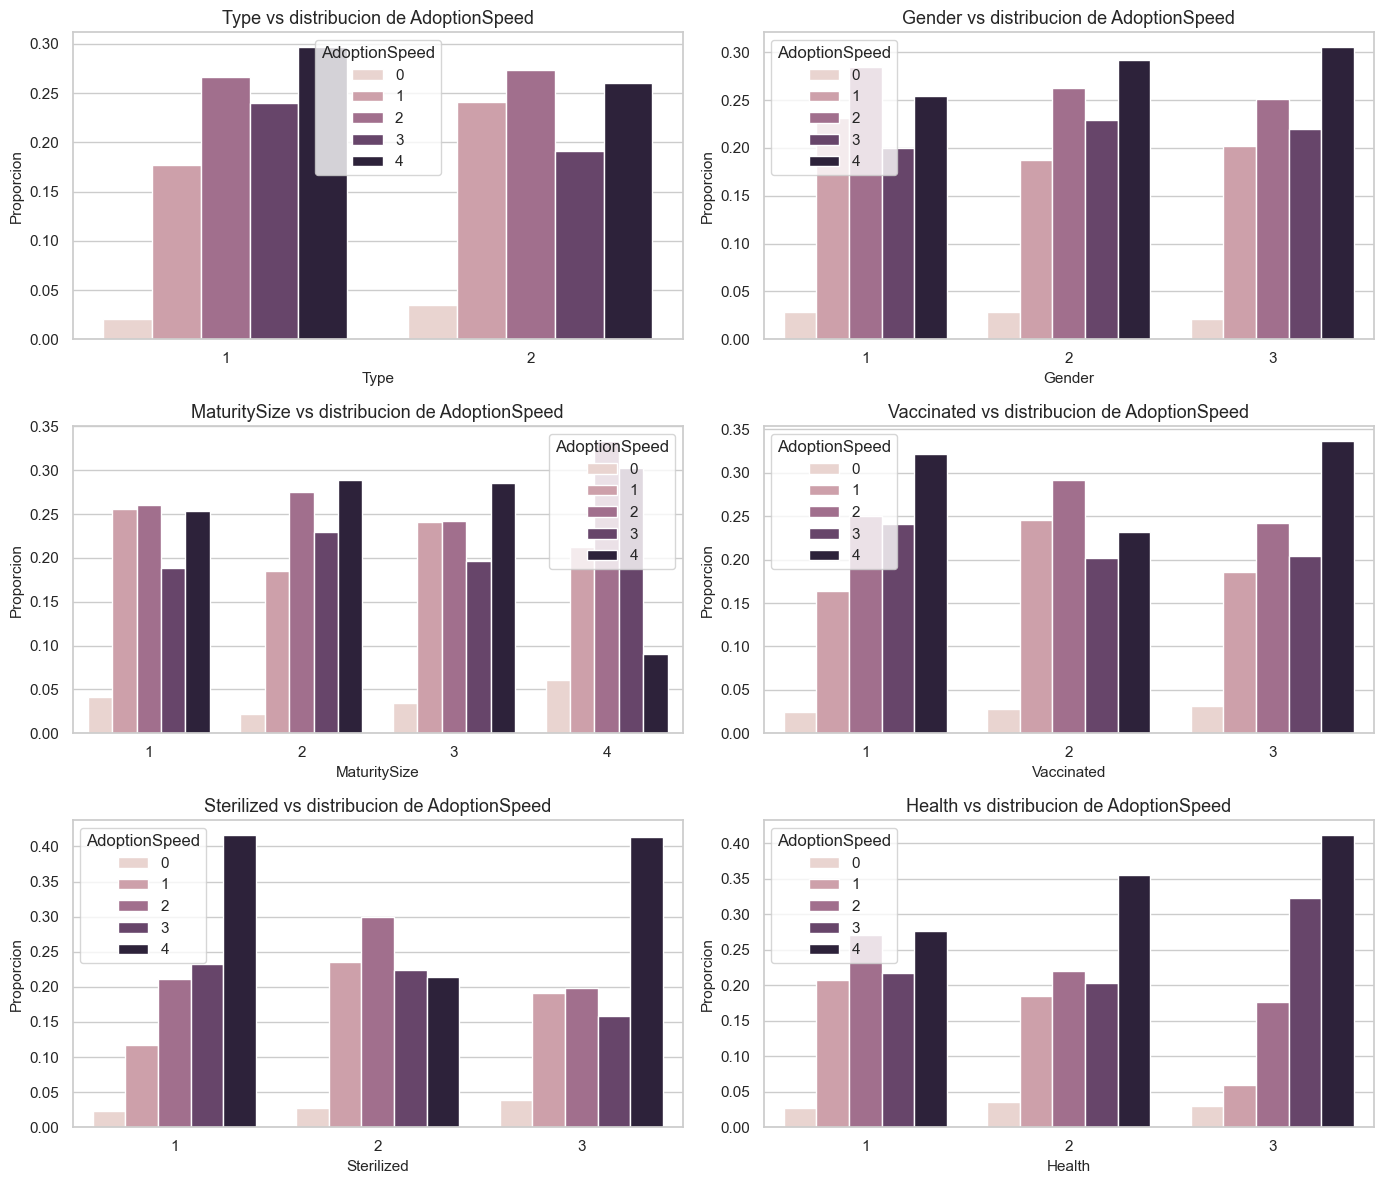

In [22]:
# Distribucion de categoricas respecto de la variable objetivo
fig, axes = plt.subplots(3, 2, figsize=(14, 12))
axes = axes.flatten()

for i, col in enumerate(selected_cats):
    prop_df = (
        dataset.groupby(col)[target_col]
        .value_counts(normalize=True)
        .rename("proportion")
        .reset_index()
    )
    sns.barplot(data=prop_df, x=col, y="proportion", hue=target_col, ax=axes[i])
    axes[i].set_title(f"{col} vs distribucion de AdoptionSpeed")
    axes[i].set_ylabel("Proporcion")
    axes[i].legend(title="AdoptionSpeed")

plt.tight_layout()
plt.show()

## Analisis bivariado de variables relevantes

En esta seccion exploramos relaciones simples entre algunas variables explicativas y la variable objetivo `AdoptionSpeed`.

El objetivo no es sacar conclusiones causales, sino detectar patrones que puedan resultar utiles en una futura tarea de clasificacion.

In [23]:
# Mapeos simples para mejorar legibilidad en algunos graficos
type_map = {1: 'Dog', 2: 'Cat'}
yes_no_map = {1: 'Yes', 2: 'No', 3: 'Not Sure'}
health_map = {0: 'Not Specified', 1: 'Healthy', 2: 'Minor Injury', 3: 'Serious Injury'}

dataset_bi = dataset.copy()
dataset_bi['TypeLabel'] = dataset_bi['Type'].map(type_map).fillna(dataset_bi['Type'].astype(str))
dataset_bi['VaccinatedLabel'] = dataset_bi['Vaccinated'].map(yes_no_map).fillna(dataset_bi['Vaccinated'].astype(str))
dataset_bi['SterilizedLabel'] = dataset_bi['Sterilized'].map(yes_no_map).fillna(dataset_bi['Sterilized'].astype(str))
dataset_bi['HealthLabel'] = dataset_bi['Health'].map(health_map).fillna(dataset_bi['Health'].astype(str))

### Velocidad de adopcion segun si es perro o gato

Comparamos la distribucion de `AdoptionSpeed` entre perros y gatos para ver si existe un patron general de adopcion segun el tipo de mascota.

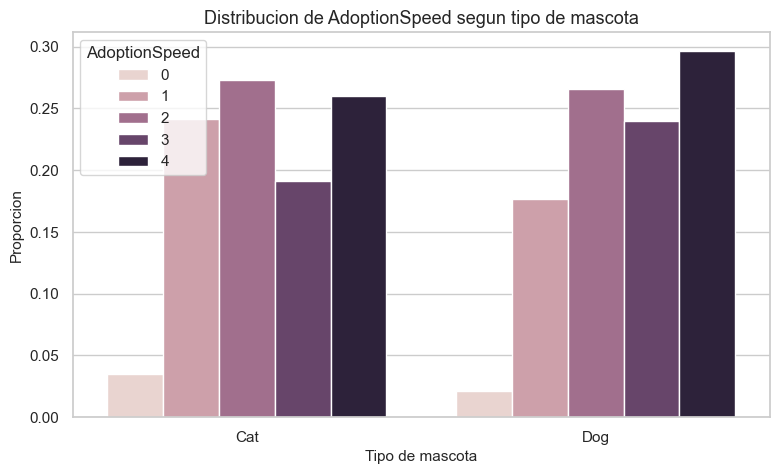

In [24]:
type_vs_target = (
    dataset_bi.groupby('TypeLabel')[target_col]
    .value_counts(normalize=True)
    .rename('proportion')
    .reset_index()
)

plt.figure(figsize=(9, 5))
sns.barplot(data=type_vs_target, x='TypeLabel', y='proportion', hue=target_col)
plt.title('Distribucion de AdoptionSpeed segun tipo de mascota')
plt.xlabel('Tipo de mascota')
plt.ylabel('Proporcion')
plt.legend(title='AdoptionSpeed')
plt.show()

### Velocidad de adopcion segun la edad

La edad puede ser una variable muy informativa. Primero observamos su distribucion por clase objetivo y luego una version agrupada por rangos para facilitar la interpretacion.

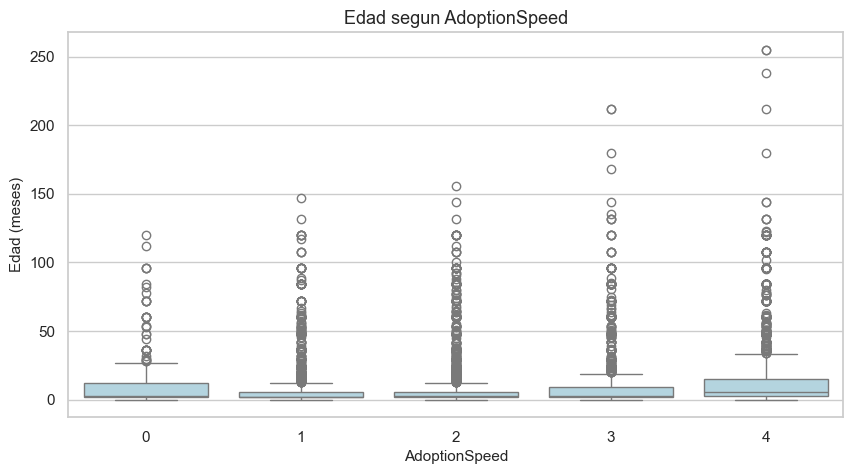

In [25]:
plt.figure(figsize=(10, 5))
sns.boxplot(data=dataset, x=target_col, y='Age', color='lightblue')
plt.title('Edad segun AdoptionSpeed')
plt.xlabel('AdoptionSpeed')
plt.ylabel('Edad (meses)')
plt.show()

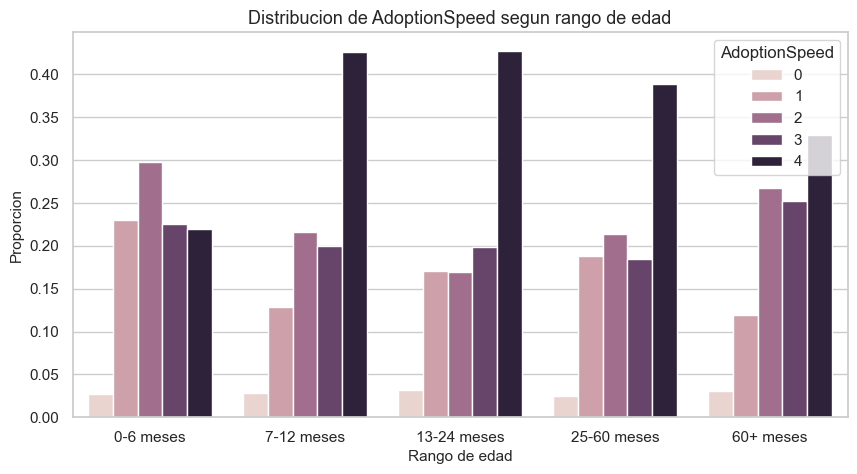

In [26]:
age_bins = [-1, 6, 12, 24, 60, dataset['Age'].max()]
age_labels = ['0-6 meses', '7-12 meses', '13-24 meses', '25-60 meses', '60+ meses']

dataset_bi['AgeGroup'] = pd.cut(dataset_bi['Age'], bins=age_bins, labels=age_labels)

agegroup_vs_target = (
    dataset_bi.groupby('AgeGroup', observed=False)[target_col]
    .value_counts(normalize=True)
    .rename('proportion')
    .reset_index()
)

plt.figure(figsize=(10, 5))
sns.barplot(data=agegroup_vs_target, x='AgeGroup', y='proportion', hue=target_col)
plt.title('Distribucion de AdoptionSpeed segun rango de edad')
plt.xlabel('Rango de edad')
plt.ylabel('Proporcion')
plt.legend(title='AdoptionSpeed')
plt.show()

### Velocidad de adopcion segun vacunacion, castracion y salud

Estas variables suelen ser importantes desde el punto de vista practico, porque pueden influir en la decision de adopcion y tambien en la calidad general del perfil de la mascota.

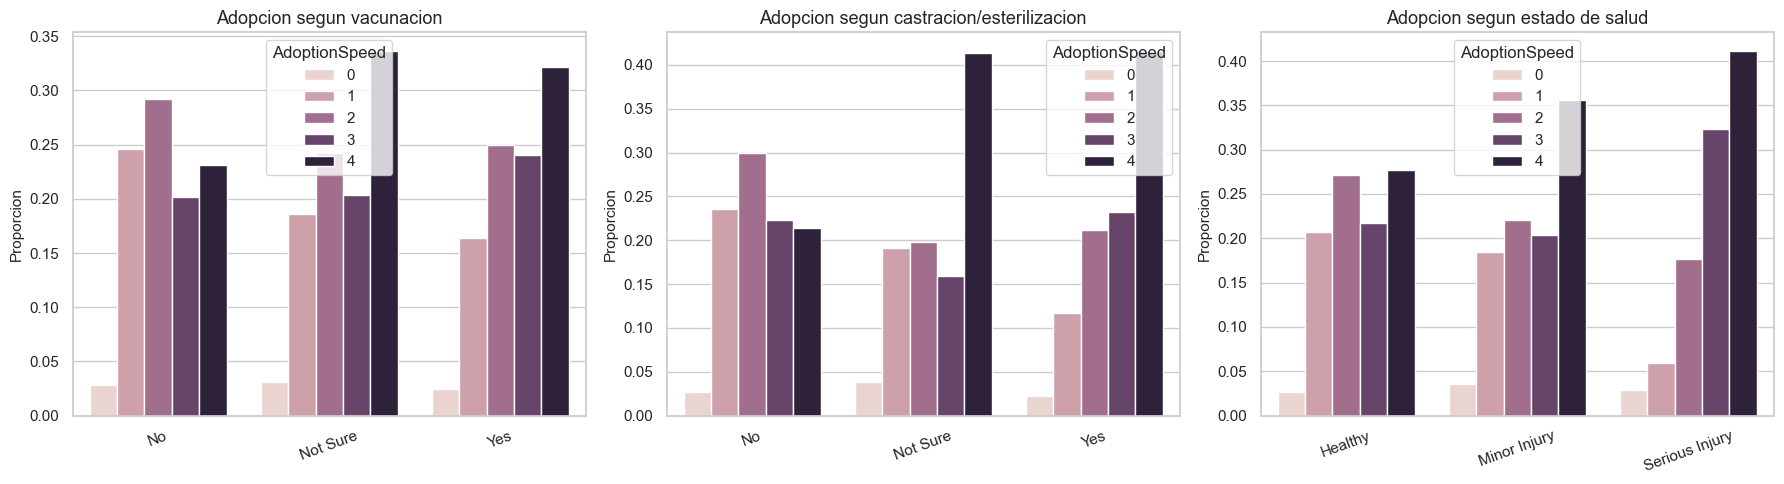

In [27]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

plot_specs = [
    ('VaccinatedLabel', 'Adopcion segun vacunacion'),
    ('SterilizedLabel', 'Adopcion segun castracion/esterilizacion'),
    ('HealthLabel', 'Adopcion segun estado de salud')
]

for ax, (col, title) in zip(axes, plot_specs):
    plot_df = (
        dataset_bi.groupby(col)[target_col]
        .value_counts(normalize=True)
        .rename('proportion')
        .reset_index()
    )
    sns.barplot(data=plot_df, x=col, y='proportion', hue=target_col, ax=ax)
    ax.set_title(title)
    ax.set_xlabel('')
    ax.set_ylabel('Proporcion')
    ax.tick_params(axis='x', rotation=20)
    ax.legend(title='AdoptionSpeed')

plt.tight_layout()
plt.show()

### Lectura preliminar de estos cruces

Estos analisis bivariados permiten detectar diferencias de distribucion entre grupos. Si aparecen patrones consistentes, esas variables probablemente sean buenas candidatas para el modelado posterior.

## Correlacion entre variables numericas

Calculamos correlacion entre variables numericas "reales".
Esto ayuda a detectar redundancias y relaciones lineales simples.

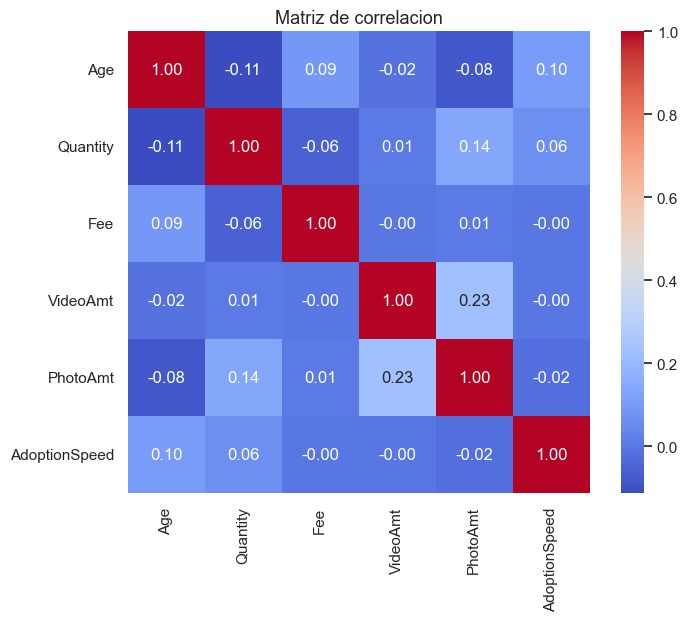

In [23]:
corr_matrix = dataset[numeric_cols + [target_col]].corr(numeric_only=True)

plt.figure(figsize=(8, 6))
sns.heatmap(corr_matrix, annot=True, cmap="coolwarm", fmt=".2f", square=True)
plt.title("Matriz de correlacion")
plt.show()

## Revision simple de outliers

Usamos el criterio de IQR para detectar posibles valores extremos en variables numericas.
Esto no implica eliminarlos ahora: solo buscamos entender su presencia.

In [24]:
outlier_rows = []

for col in numeric_cols:
    q1 = dataset[col].quantile(0.25)
    q3 = dataset[col].quantile(0.75)
    iqr = q3 - q1
    lower_bound = q1 - 1.5 * iqr
    upper_bound = q3 + 1.5 * iqr

    outliers = dataset[(dataset[col] < lower_bound) | (dataset[col] > upper_bound)][col]

    outlier_rows.append({
        "variable": col,
        "q1": q1,
        "q3": q3,
        "iqr": iqr,
        "lower_bound": lower_bound,
        "upper_bound": upper_bound,
        "n_outliers": outliers.shape[0],
        "pct_outliers": round(outliers.shape[0] / len(dataset) * 100, 2)
    })

outlier_summary = pd.DataFrame(outlier_rows).sort_values("n_outliers", ascending=False)
outlier_summary

,variable,q1,q3,iqr,lower_bound,upper_bound,n_outliers,pct_outliers
1,Quantity,1.0,1.0,0.0,1.0,1.0,3428,22.86
2,Fee,0.0,0.0,0.0,0.0,0.0,2330,15.54
0,Age,2.0,12.0,10.0,-13.0,27.0,1501,10.01
4,PhotoAmt,2.0,5.0,3.0,-2.5,9.5,922,6.15
3,VideoAmt,0.0,0.0,0.0,0.0,0.0,574,3.83


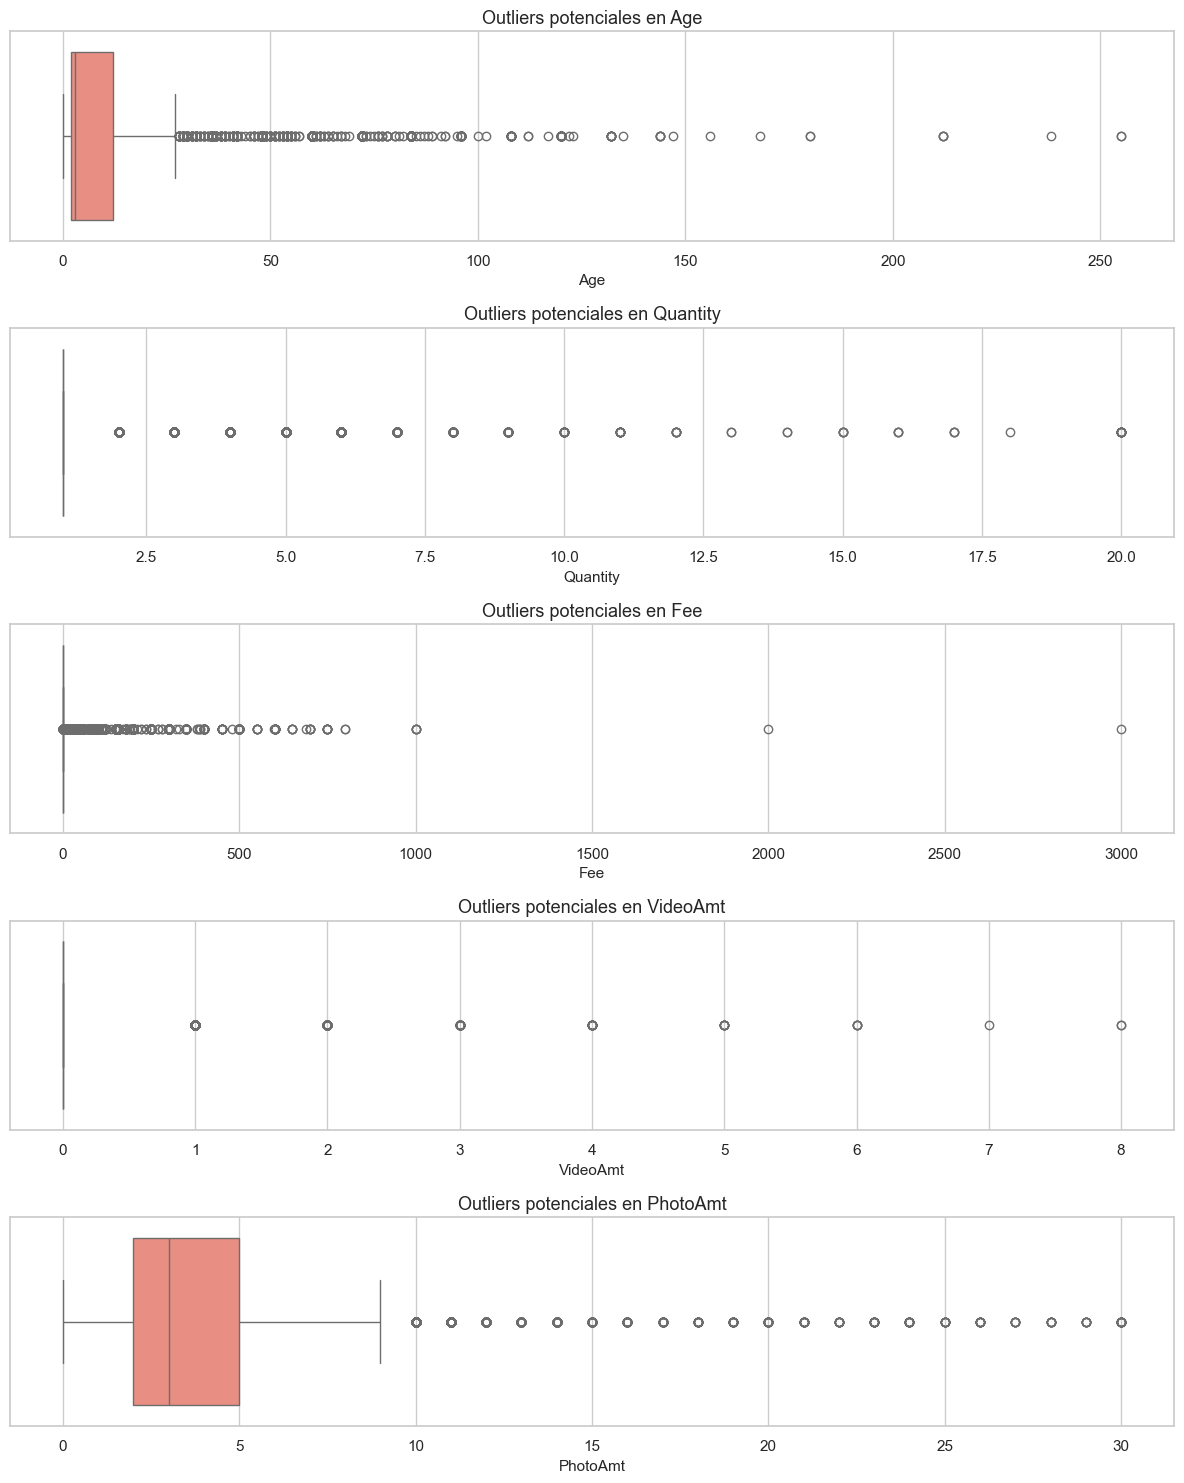

In [25]:
# Visualizacion compacta de outliers en variables numericas
fig, axes = plt.subplots(len(numeric_cols), 1, figsize=(12, 3 * len(numeric_cols)))

for ax, col in zip(axes, numeric_cols):
    sns.boxplot(data=dataset, x=col, ax=ax, color="salmon")
    ax.set_title(f"Outliers potenciales en {col}")

plt.tight_layout()
plt.show()

## Conclusiones del EDA

A continuacion, resumimos los hallazgos principales del analisis exploratorio.

In [26]:
print("Conclusiones principales del EDA:\n")

print("1. El dataset tiene un tamano adecuado para una primera tarea de clasificacion supervisada.")
print("2. La variable objetivo `AdoptionSpeed` presenta varias clases y no esta perfectamente balanceada.")
print("3. Hay pocos valores faltantes, concentrados principalmente en `Name` y `Description`.")
print("4. Existen variables numericas con fuerte asimetria y posibles outliers, especialmente `Fee`, `Quantity`, `VideoAmt` y `PhotoAmt`.")
print("5. Muchas columnas enteras representan categorias codificadas, por lo que no deben interpretarse como variables continuas.")
print("6. Variables como `Type`, `Gender`, `MaturitySize`, `Vaccinated`, `Sterilized` y `Health` parecen relevantes para explicar diferencias en `AdoptionSpeed`.")
print("7. `RescuerID`, `PetID`, `Name` y `Description` requeriran un tratamiento especifico mas adelante, pero en esta etapa solo se identifican como fuentes potenciales de informacion.")
print("8. No se observa, en principio, una correlacion lineal muy fuerte entre las variables numericas reales, lo cual reduce riesgo de multicolinealidad severa en ese subconjunto.")
print("9. Antes de modelar, sera importante definir estrategia para:")
print("   - imputacion de faltantes,")
print("   - tratamiento de variables categoricas,")
print("   - uso o exclusion de texto e identificadores,")
print("   - posible manejo de outliers segun el modelo elegido.")

Conclusiones principales del EDA:

1. El dataset tiene un tamano adecuado para una primera tarea de clasificacion supervisada.
2. La variable objetivo `AdoptionSpeed` presenta varias clases y no esta perfectamente balanceada.
3. Hay pocos valores faltantes, concentrados principalmente en `Name` y `Description`.
4. Existen variables numericas con fuerte asimetria y posibles outliers, especialmente `Fee`, `Quantity`, `VideoAmt` y `PhotoAmt`.
5. Muchas columnas enteras representan categorias codificadas, por lo que no deben interpretarse como variables continuas.
6. Variables como `Type`, `Gender`, `MaturitySize`, `Vaccinated`, `Sterilized` y `Health` parecen relevantes para explicar diferencias en `AdoptionSpeed`.
7. `RescuerID`, `PetID`, `Name` y `Description` requeriran un tratamiento especifico mas adelante, pero en esta etapa solo se identifican como fuentes potenciales de informacion.
8. No se observa, en principio, una correlacion lineal muy fuerte entre las variables numericas rea

## Cierre

Este EDA permitio comprender la estructura del dataset, la distribucion de la variable objetivo y algunos aspectos clave de calidad de datos.

El proximo paso, en una etapa posterior, sera preparar un pipeline de preprocesamiento adecuado para clasificacion, sin perder de vista:
- el tratamiento de variables categoricas,
- el posible valor del texto,
- y el desbalance moderado de la variable objetivo.